In [3]:
import pandas as pd
import numpy as np
from scipy.sparse import coo_matrix

train_df = pd.read_csv("data/processed/training_data.csv")
test_df = pd.read_csv("data/processed/testing_data.csv")

user_ids = pd.concat([train_df.user_id, test_df.user_id]).unique()
movie_ids = pd.concat([train_df.movie_id, test_df.movie_id]).unique()

In [7]:
user_map = {u: i for i, u in enumerate(user_ids)}
movie_map = {m: i for i, m in enumerate(movie_ids)}

In [ ]:
train_users = train_df.user_id.map(user_map).values
train_movies = train_df.movie_id.map(movie_map).values
train_ratings = train_df.rating.values
test_ratings = test_df.rating.values
test_users = test_df.user_id.map(user_map).values
test_movies = test_df.movie_id.map(movie_map).values

In [26]:
n_users = len(user_ids)
n_movies = len(movie_ids)

R = coo_matrix((train_ratings, (train_users, train_movies)), shape=(n_users, n_movies))

R_csr = R.tocsr()
R_csc = R.tocsc()

In [27]:
results = []

k_list = [20, 50, 100]
n_iters_list = [15, 25, 30]
lambda_list = [0.1, 0.2, 0.4]

for k in k_list:
    for n_iters in n_iters_list:
        for lambda_reg in lambda_list:
            
            P = np.random.normal(scale=1.0/k, size=(n_users, k))
            Q = np.random.normal(scale=1.0/k, size=(n_movies, k))
            
            for _ in range(n_iters):
                for u in range(n_users):
                    start, end = R_csr.indptr[u], R_csr.indptr[u+1]
                    if start == end:
                        continue
                    items = R_csr.indices[start:end]
                    ratings = R_csr.data[start:end]
                    Q_i = Q[items]
                    A = Q_i.T @ Q_i + lambda_reg * np.eye(k)
                    b = Q_i.T @ ratings
                    P[u] = np.linalg.solve(A, b)
                
                for i in range(n_movies):
                    start, end = R_csc.indptr[i], R_csc.indptr[i+1]
                    if start == end:
                        continue
                    users = R_csc.indices[start:end]
                    ratings = R_csc.data[start:end]
                    P_u = P[users]
                    A = P_u.T @ P_u + lambda_reg * np.eye(k)
                    b = P_u.T @ ratings
                    Q[i] = np.linalg.solve(A, b)
            
            predictions = np.sum(P[test_users] * Q[test_movies], axis=1)
            
            errors = test_ratings - predictions
            RMSE = np.sqrt(np.mean(errors**2))
            MAE = np.mean(np.abs(errors))
            
            results.append({
                'k': k,
                'n_iter': n_iters,
                'lambda_reg': lambda_reg,
                'MAE': MAE,
                'RMSE': RMSE
            })
            
            print(f"k={k}, n_iter={n_iters}, lambda_reg={lambda_reg} -> MAE={MAE:.4f}, RMSE={RMSE:.4f}")

results_df = pd.DataFrame(results)
results_df.to_csv("als_hyperparam_results.csv", index=False)

/var/folders/_n/4cslc53j6ls8_fsjchkctxkh0000gn/T/ipykernel_12235/3673325776.py:22: RuntimeWarning: divide by zero encountered in matmul
  A = Q_i.T @ Q_i + lambda_reg * np.eye(k)
/var/folders/_n/4cslc53j6ls8_fsjchkctxkh0000gn/T/ipykernel_12235/3673325776.py:22: RuntimeWarning: overflow encountered in matmul
  A = Q_i.T @ Q_i + lambda_reg * np.eye(k)
/var/folders/_n/4cslc53j6ls8_fsjchkctxkh0000gn/T/ipykernel_12235/3673325776.py:22: RuntimeWarning: invalid value encountered in matmul
  A = Q_i.T @ Q_i + lambda_reg * np.eye(k)
/var/folders/_n/4cslc53j6ls8_fsjchkctxkh0000gn/T/ipykernel_12235/3673325776.py:23: RuntimeWarning: divide by zero encountered in matmul
  b = Q_i.T @ ratings
/var/folders/_n/4cslc53j6ls8_fsjchkctxkh0000gn/T/ipykernel_12235/3673325776.py:23: RuntimeWarning: overflow encountered in matmul
  b = Q_i.T @ ratings
/var/folders/_n/4cslc53j6ls8_fsjchkctxkh0000gn/T/ipykernel_12235/3673325776.py:23: RuntimeWarning: invalid value encountered in matmul
  b = Q_i.T @ ratings
/va

k=20, n_iter=15, lambda_reg=0.1 -> MAE=0.6479, RMSE=0.8470
k=20, n_iter=15, lambda_reg=0.2 -> MAE=0.6492, RMSE=0.8487
k=20, n_iter=15, lambda_reg=0.4 -> MAE=0.6488, RMSE=0.8478
k=20, n_iter=25, lambda_reg=0.1 -> MAE=0.6515, RMSE=0.8547
k=20, n_iter=25, lambda_reg=0.2 -> MAE=0.6512, RMSE=0.8542
k=20, n_iter=25, lambda_reg=0.4 -> MAE=0.6506, RMSE=0.8527
k=20, n_iter=30, lambda_reg=0.1 -> MAE=0.6522, RMSE=0.8567
k=20, n_iter=30, lambda_reg=0.2 -> MAE=0.6516, RMSE=0.8551
k=20, n_iter=30, lambda_reg=0.4 -> MAE=0.6511, RMSE=0.8534
k=50, n_iter=15, lambda_reg=0.1 -> MAE=0.6908, RMSE=0.9286
k=50, n_iter=15, lambda_reg=0.2 -> MAE=0.6874, RMSE=0.9203
k=50, n_iter=15, lambda_reg=0.4 -> MAE=0.6847, RMSE=0.9135
k=50, n_iter=25, lambda_reg=0.1 -> MAE=0.6993, RMSE=0.9522
k=50, n_iter=25, lambda_reg=0.2 -> MAE=0.6956, RMSE=0.9415
k=50, n_iter=25, lambda_reg=0.4 -> MAE=0.6921, RMSE=0.9320
k=50, n_iter=30, lambda_reg=0.1 -> MAE=0.7007, RMSE=0.9570
k=50, n_iter=30, lambda_reg=0.2 -> MAE=0.6980, RMSE=0.94

KeyboardInterrupt: 

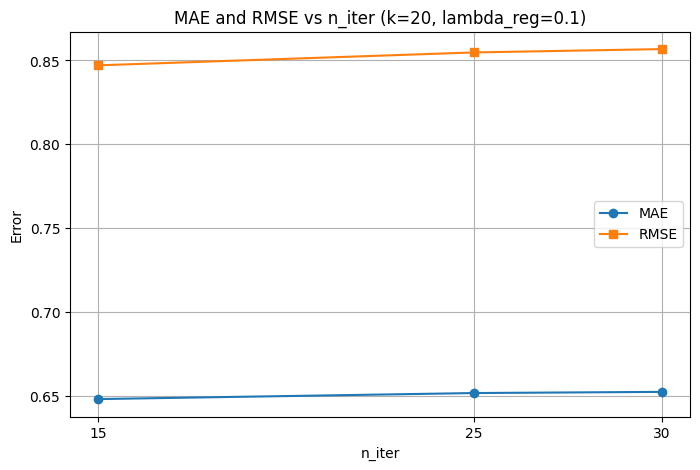

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mae_rmse.csv")

subset = df[(df['k'] == 20) & (df['lambda_reg'] == 0.1)]

x = subset['n_iter']

mae = subset['MAE']
rmse = subset['RMSE']

plt.figure(figsize=(8,5))
plt.plot(x, mae, marker='o', label='MAE')
plt.plot(x, rmse, marker='s', label='RMSE')
plt.title('MAE and RMSE vs n_iter (k=20, lambda_reg=0.1)')
plt.xlabel('n_iter')
plt.ylabel('Error')
plt.xticks(x)
plt.grid(True)
plt.legend()
plt.show()

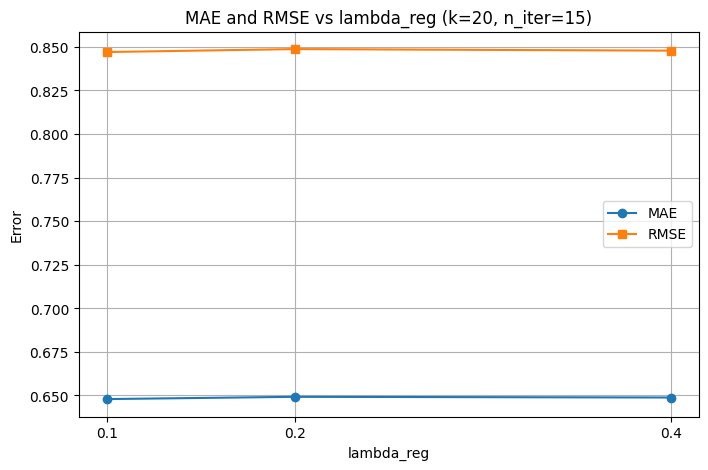

In [34]:
subset2 = df[(df['k'] == 20) & (df['n_iter'] == 15)]

x2 = subset2['lambda_reg']

mae2 = subset2['MAE']
rmse2 = subset2['RMSE']

plt.figure(figsize=(8,5))
plt.plot(x2, mae2, marker='o', label='MAE')
plt.plot(x2, rmse2, marker='s', label='RMSE')
plt.title('MAE and RMSE vs lambda_reg (k=20, n_iter=15)')
plt.xlabel('lambda_reg')
plt.ylabel('Error')
plt.xticks(x2)
plt.grid(True)
plt.legend()
plt.show()

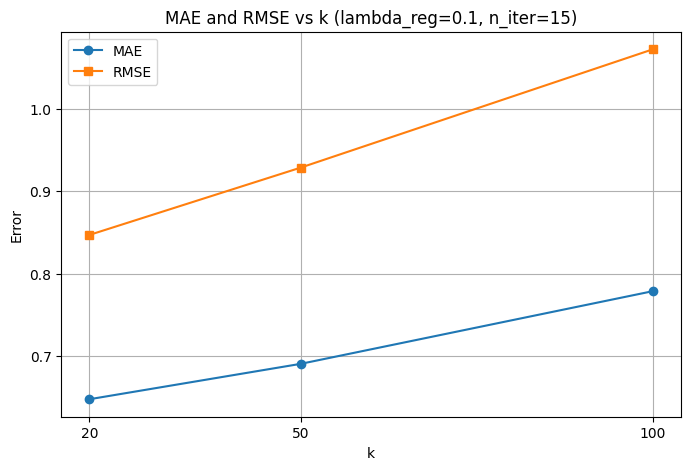

In [36]:
subset3 = df[(df['lambda_reg'] == 0.1) & (df['n_iter'] == 15)]

x3 = subset3['k']

mae3 = subset3['MAE']
rmse3 = subset3['RMSE']

plt.figure(figsize=(8,5))
plt.plot(x3, mae3, marker='o', label='MAE')
plt.plot(x3, rmse3, marker='s', label='RMSE')
plt.title('MAE and RMSE vs k (lambda_reg=0.1, n_iter=15)')
plt.xlabel('k')
plt.ylabel('Error')
plt.xticks(x3)
plt.grid(True)
plt.legend()
plt.show()